# Phase 8 — Faust Vp: Resistivity-to-Velocity Modelling

**Well**: 15/9-F-1 A · **Field**: Volve, Norwegian North Sea

The **Faust (1953) equation** estimates compressional velocity from formation resistivity and depth, providing synthetic Vp in intervals where the acoustic log is absent, unreliable, or has not been acquired.

**When Faust is applied:**
- Wells drilled without a sonic tool (common in older vintage wells)
- Shallow sections above the sonic logging start depth
- Intervals with severe cycle skipping that cannot be repaired
- As an independent check on measured Vp in shale-dominated intervals

**The Faust equation:**
$$V_p \; [\text{m/s}] = C \times (Z_{\text{TVD}} \; [\text{ft}] \times R_t \; [\Omega \cdot \text{m}])^{1/6}$$

Both depth $Z$ and resistivity $R_t$ act as proxies for **compaction state** — deeper, more resistive formations tend to be faster. The empirical constant $C$ must be calibrated well-by-well against intervals where Vp is measured.

**Limitations:** Faust works best in monotonic, shale-dominated compaction sequences. It deteriorates where:
- HC saturation elevates $R_t$ without increasing $V_p$ (gas sands)
- Lithology heterogeneity breaks the single $C$ assumption
- Cementation creates high $V_p$ without high $R_t$ (tight carbonates)

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from scipy import stats
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
WELL_FILE    = Path('../wells/15_9-F-1A.LAS')
TOPS_FILE    = Path('../wells/Volve_formation_tops.csv')
COMPUTED_IN  = Path('../wells/15_9-F-1A_computed.parquet')
FLAGS_IN     = Path('../wells/15_9-F-1A_flags.parquet')
ELASTIC_IN   = Path('../wells/15_9-F-1A_elastic.parquet')
RHOB_OK_IN   = Path('../wells/15_9-F-1A_rhob_ok.parquet')
OUT_FILE     = Path('../wells/15_9-F-1A_faust.parquet')

# ── Faust calibration domain ─────────────────────────────────────────────────
RT_CALIB_MAX = 10.0   # Ω·m — exclude HC-elevated Rt from calibration
RT_CALIB_MIN = 0.2    # Ω·m — exclude very low Rt (possible mud contamination)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 9,
    'axes.linewidth': 0.8, 'xtick.direction': 'in', 'ytick.direction': 'in',
    'figure.dpi': 120,
})

## Step 8.1 — Load Data

In [2]:
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.index.name = 'DEPTH_MD'

df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')
df = df.join(pd.read_parquet(ELASTIC_IN),  how='left')
df = df.join(pd.read_parquet(RHOB_OK_IN),  how='left')

f1a = (
    pd.read_csv(TOPS_FILE)
    .query("`WELL` == 'NO 15/9-F-1 A'")
    .sort_values('DEPTH').drop_duplicates(subset='DEPTH').reset_index(drop=True)
)

def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

LOG_TOP, LOG_BASE = 2605, 3680
sub = df.loc[LOG_TOP:LOG_BASE].copy()

TOPS_MD = {
    'Ty Fm': 2621.5, 'Shetland GP': 2770.6, 'Hod Fm': 2987.0,
    'Draupne Fm': 3358.0, 'Heather Fm': 3429.4, 'Hugin Fm': 3435.0,
    'Sleipner Fm': 3500.2, 'Skagerrak Fm': 3543.7, 'Smith Bank Fm': 3608.0,
}
FORM_COLORS = {
    'Ty Fm': '#2E86C1', 'Shetland GP': '#85C1E9', 'Hod Fm': '#AED6F1',
    'Draupne Fm': '#1A5276', 'Heather Fm': '#784212', 'Hugin Fm': '#E74C3C',
    'Sleipner Fm': '#1E8449', 'Skagerrak Fm': '#7D3C98', 'Smith Bank Fm': '#B7950B',
}
top_mds = sorted(TOPS_MD.items(), key=lambda x: x[1])
sub['FORMATION'] = 'Other'
for name, md_top in top_mds:
    sub.loc[sub.index >= md_top, 'FORMATION'] = name

# Depth in feet (Faust requires TVD in feet)
sub['Z_ft'] = sub['TVDSS_ABS'] * 3.28084

print(f"Interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)")
print(f"RT range: {sub['RT'].min():.2f} – {sub['RT'].max():.1f} Ω·m")
print(f"Z_ft range: {sub['Z_ft'].min():.0f} – {sub['Z_ft'].max():.0f} ft")

Interval: 2605–3680 m MD  (10,751 samples)
RT range: 0.14 – 46224.4 Ω·m
Z_ft range: 7886 – 10274 ft


## Step 8.2 — Identify the Calibration Domain

The Faust constant $C$ is calibrated on intervals where:
1. **Measured Vp is available** (DT valid)
2. **$R_t$ is dominated by lithology/compaction**, not hydrocarbon saturation

Criterion (2) means excluding HC-elevated resistivity. We use $R_t < 10$ Ω·m as the threshold: above this, resistivity is more likely to reflect gas or oil saturation than rock properties.

Intervals with $R_t > 10$ Ω·m (HC-saturated reservoir) are excluded from calibration but will still receive a Faust Vp prediction — the Faust velocity will *underestimate* Vp in gas sands (gas raises $R_t$ but also lowers Vp), which is an expected and documentable artefact.

Vp available     : 10,224 samples
Calibration zone : 9,869 samples  (RT 0.2–10.0 Ω·m)
HC-elevated zone : 353 samples  (RT > 10.0 Ω·m — excluded from calibration)



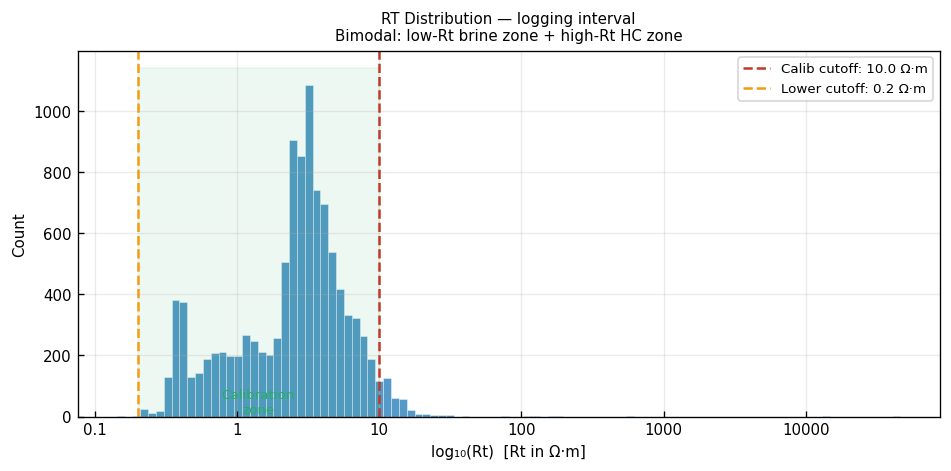

In [3]:
# ── Calibration mask ──────────────────────────────────────────────────────────
calib_mask = (
    sub['VP'].notna() &
    sub['RT'].notna() & (sub['RT'] > RT_CALIB_MIN) & (sub['RT'] < RT_CALIB_MAX) &
    sub['Z_ft'].notna() & (sub['Z_ft'] > 0)
)

n_total   = sub['VP'].notna().sum()
n_calib   = calib_mask.sum()
n_hc      = (sub['RT'] > RT_CALIB_MAX).sum()

print(f"Vp available     : {n_total:,} samples")
print(f"Calibration zone : {n_calib:,} samples  (RT {RT_CALIB_MIN}–{RT_CALIB_MAX} Ω·m)")
print(f"HC-elevated zone : {n_hc:,} samples  (RT > {RT_CALIB_MAX} Ω·m — excluded from calibration)")
print()

# RT distribution
rt_log = np.log10(sub['RT'].dropna())
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rt_log, bins=100, color='#2980B9', edgecolor='white', lw=0.3, alpha=0.8)
ax.axvline(np.log10(RT_CALIB_MAX), color='#C0392B', lw=1.5, ls='--',
           label=f'Calib cutoff: {RT_CALIB_MAX} Ω·m')
ax.axvline(np.log10(RT_CALIB_MIN), color='#F39C12', lw=1.5, ls='--',
           label=f'Lower cutoff: {RT_CALIB_MIN} Ω·m')
ax.set_xlabel('log₁₀(Rt)  [Rt in Ω·m]', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_title('RT Distribution — logging interval\n'
             'Bimodal: low-Rt brine zone + high-Rt HC zone', fontsize=9)
# Custom x tick labels
ticks = [-1, 0, 1, 2, 3, 4, 5]
ax.set_xticks(ticks)
ax.set_xticklabels([f'0.1' if t==-1 else f'{10**t:.0f}' for t in ticks])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 2000],
                  np.log10(RT_CALIB_MIN), np.log10(RT_CALIB_MAX),
                  alpha=0.08, color='#27AE60')
ax.text((np.log10(RT_CALIB_MIN)+np.log10(RT_CALIB_MAX))/2, 0,
        'Calibration\nzone', ha='center', va='bottom', fontsize=8, color='#27AE60')
plt.tight_layout()
plt.show()

## Step 8.3 — Global Calibration: Solve for Constant C

With the calibration mask defined, we solve for $C$ by rearranging the Faust equation:

$$C = \frac{V_p^{\text{meas}}}{(Z_{\text{TVD}} \cdot R_t)^{1/6}}$$

We use the **geometric mean** of the per-sample $C$ values (equivalent to a log-space arithmetic mean) as the best single-C estimate. The geometric mean is more robust than the arithmetic mean for log-normally distributed quantities like velocity and resistivity.

We also test whether the Faust exponent of 1/6 is appropriate for this dataset by running a free-exponent log-space regression.

In [4]:
vp_c   = sub.loc[calib_mask, 'VP'].values
z_ft_c = sub.loc[calib_mask, 'Z_ft'].values
rt_c   = sub.loc[calib_mask, 'RT'].values

# ── Geometric mean C (forced 1/6 exponent) ────────────────────────────────────
faust_arg_c = (z_ft_c * rt_c) ** (1/6)
C_per_sample = vp_c / faust_arg_c
C_global = float(np.exp(np.mean(np.log(C_per_sample))))

vp_faust_calib = C_global * faust_arg_c
rms_global = float(np.sqrt(np.mean((vp_c - vp_faust_calib)**2)))
r2_global  = float(1 - np.sum((vp_c - vp_faust_calib)**2) / np.sum((vp_c - vp_c.mean())**2))

# ── Free-exponent log-space regression ───────────────────────────────────────
log_vp   = np.log(vp_c)
log_prod = np.log(z_ft_c * rt_c)
slope, intercept, r, _, _ = stats.linregress(log_prod, log_vp)
C_free = float(np.exp(intercept))
exp_free = float(slope)

vp_faust_free = C_free * (z_ft_c * rt_c) ** exp_free
rms_free = float(np.sqrt(np.mean((vp_c - vp_faust_free)**2)))
r2_free  = float(r**2)

print("Faust calibration results:")
print(f"  Calibration samples : {n_calib:,}")
print()
print(f"  Fixed exponent (1/6 = 0.1667):")
print(f"    C_global       : {C_global:.1f}")
print(f"    RMS error      : {rms_global:.0f} m/s")
print(f"    R²             : {r2_global:.3f}")
print()
print(f"  Free-exponent regression:")
print(f"    C_free         : {C_free:.1f}")
print(f"    Exponent       : {exp_free:.4f}  (Faust = 0.1667)")
print(f"    RMS error      : {rms_free:.0f} m/s")
print(f"    R²             : {r2_free:.3f}")
print()
print("Interpretation:")
print(f"  The best-fit exponent ({exp_free:.3f}) departs from the Faust 1/6 assumption.")
print(f"  This is typical for lithologically heterogeneous sections where depth")
print(f"  and Rt are not the only drivers of velocity variation.")
print(f"  Faust remains useful as a 1st-order Vp estimate in data-sparse intervals.")
print(f"\n  Mean Vp in calibration zone: {vp_c.mean():.0f} m/s")
print(f"  RMS as % of mean Vp:         {100*rms_global/vp_c.mean():.1f}%")

Faust calibration results:
  Calibration samples : 9,869

  Fixed exponent (1/6 = 0.1667):
    C_global       : 763.9
    RMS error      : 522 m/s
    R²             : 0.232

  Free-exponent regression:
    C_free         : 1503.8
    Exponent       : 0.0985  (Faust = 0.1667)
    RMS error      : 477 m/s
    R²             : 0.330

Interpretation:
  The best-fit exponent (0.099) departs from the Faust 1/6 assumption.
  This is typical for lithologically heterogeneous sections where depth
  and Rt are not the only drivers of velocity variation.
  Faust remains useful as a 1st-order Vp estimate in data-sparse intervals.

  Mean Vp in calibration zone: 4051 m/s
  RMS as % of mean Vp:         12.9%


## Step 8.4 — Per-Formation Calibration

Faust accuracy improves when each formation is calibrated independently with its own constant. This accounts for changes in lithology, fluid type, and cementation style between stratigraphic units.

In [5]:
form_constants = {}  # {formation_name: C_value}

print("Per-formation Faust calibration:")
print(f"{'Formation':<20} {'n_calib':>8} {'C':>8} {'RMS (m/s)':>10} {'R²':>7} {'Notes'}")
print("─" * 80)

top_list = sorted(TOPS_MD.items(), key=lambda x: x[1])
for i, (name, md_top) in enumerate(top_list):
    md_base = top_list[i+1][1] if i+1 < len(top_list) else LOG_BASE
    fm = sub.loc[md_top:md_base]

    fmask = (
        fm['VP'].notna() &
        fm['RT'].notna() & (fm['RT'] > RT_CALIB_MIN) & (fm['RT'] < RT_CALIB_MAX) &
        fm['Z_ft'].notna() & (fm['Z_ft'] > 0)
    )

    if fmask.sum() < 30:
        form_constants[name] = C_global
        print(f"{name:<20} {fmask.sum():>8} {'—':>8} {'—':>10} {'—':>7} "
              f"< 30 pts, using global C={C_global:.0f}")
        continue

    vp_f   = fm.loc[fmask, 'VP'].values
    z_f    = fm.loc[fmask, 'Z_ft'].values
    rt_f   = fm.loc[fmask, 'RT'].values
    fa_f   = (z_f * rt_f) ** (1/6)
    C_f    = float(np.exp(np.mean(np.log(vp_f / fa_f))))

    vp_pred_f = C_f * fa_f
    rms_f = float(np.sqrt(np.mean((vp_f - vp_pred_f)**2)))
    r2_f  = float(1 - np.sum((vp_f - vp_pred_f)**2) / np.sum((vp_f - vp_f.mean())**2))

    form_constants[name] = C_f

    quality = 'good' if r2_f > 0.3 else ('fair' if r2_f > 0.1 else 'poor')
    print(f"{name:<20} {fmask.sum():>8,} {C_f:>8.1f} {rms_f:>10.0f} {r2_f:>7.3f}  [{quality}]")

Per-formation Faust calibration:
Formation             n_calib        C  RMS (m/s)      R² Notes
────────────────────────────────────────────────────────────────────────────────
Ty Fm                   1,461    797.2        378  -2.319  [poor]
Shetland GP             2,106    821.6        260   0.473  [good]
Hod Fm                  3,508    750.6        206   0.407  [good]
Draupne Fm                700    510.4        364  -1.578  [poor]
Heather Fm                 56    799.7        429  -4.174  [poor]
Hugin Fm                  608    824.0        451  -0.255  [poor]
Sleipner Fm               436    781.8        214   0.518  [good]
Skagerrak Fm              644    850.6        229   0.129  [fair]
Smith Bank Fm             342    768.7        159   0.113  [fair]


## Step 8.5 — Calibration Crossplot: Vp_measured vs Vp_Faust

A 1:1 crossplot between the measured and Faust-predicted Vp is the primary calibration quality check. Systematic bias (points consistently above or below 1:1) can be reduced by adjusting $C$. High scatter reflects the fundamental limitation of single-parameter (resistivity) velocity prediction.

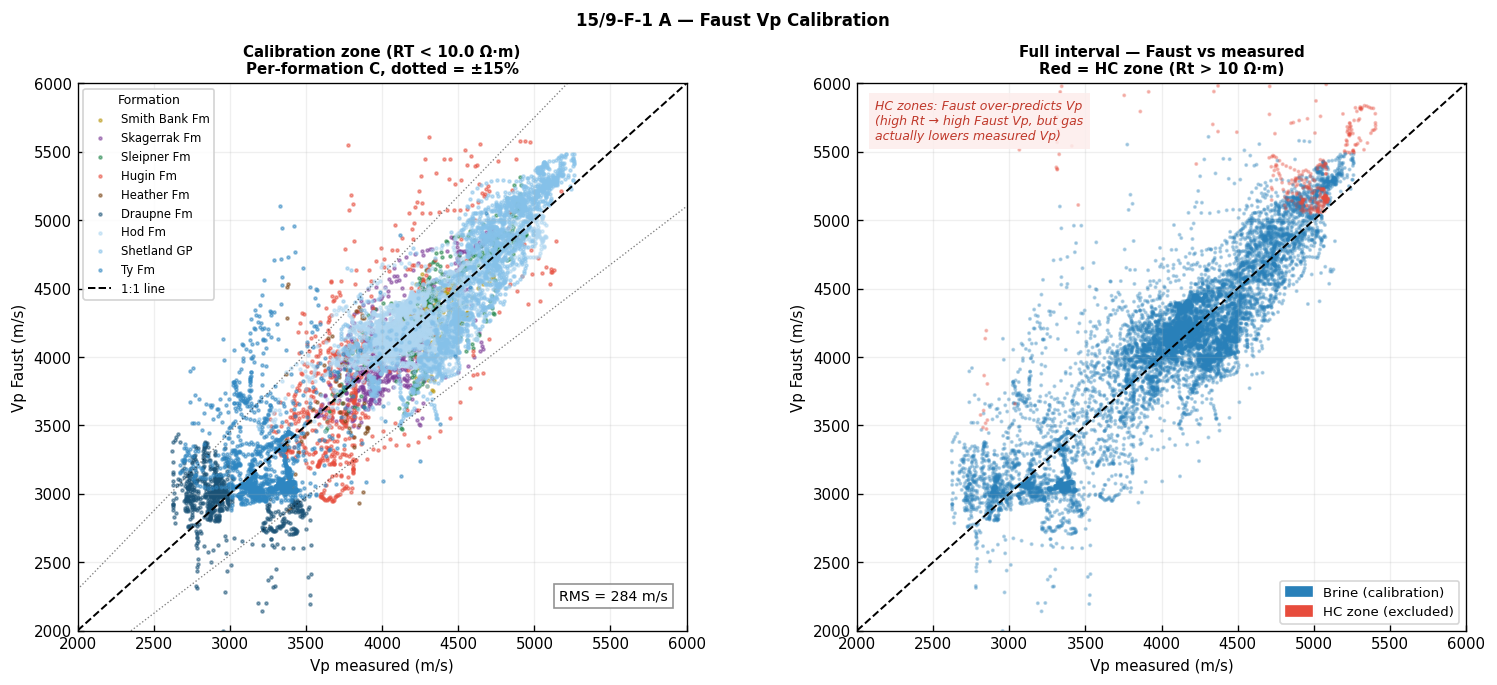

In [6]:
# Apply per-formation C to compute VP_FAUST on calibration zone
sub['C_FAUST'] = C_global  # default
for name, C_val in form_constants.items():
    sub.loc[sub['FORMATION'] == name, 'C_FAUST'] = C_val

# Compute Faust Vp everywhere RT is valid
valid_rt = sub['RT'].notna() & (sub['RT'] > 0) & sub['Z_ft'].notna() & (sub['Z_ft'] > 0)
faust_arg_all = (sub.loc[valid_rt, 'Z_ft'] * sub.loc[valid_rt, 'RT']) ** (1/6)
sub.loc[valid_rt, 'VP_FAUST'] = sub.loc[valid_rt, 'C_FAUST'] * faust_arg_all

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.28)

# Left: calibration zone crossplot coloured by formation
ax = axes[0]
for form_name in list(TOPS_MD.keys())[::-1]:
    fm = sub[(sub['FORMATION'] == form_name) & calib_mask]
    if len(fm) == 0: continue
    ax.scatter(fm['VP'], fm['VP_FAUST'],
               s=3, alpha=0.5, rasterized=True,
               color=FORM_COLORS.get(form_name, '#888'), label=form_name)

lim = [2000, 6000]
ax.plot(lim, lim, 'k--', lw=1.2, label='1:1 line')
ax.plot(lim, [v*1.15 for v in lim], 'k:', lw=0.8, alpha=0.5)
ax.plot(lim, [v*0.85 for v in lim], 'k:', lw=0.8, alpha=0.5)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('Vp measured (m/s)', fontsize=9)
ax.set_ylabel('Vp Faust (m/s)', fontsize=9)
ax.set_title(f'Calibration zone (RT < {RT_CALIB_MAX} Ω·m)\n'
             f'Per-formation C, dotted = ±15%', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, loc='upper left', framealpha=0.85,
          title='Formation', title_fontsize=7.5)
ax.grid(True, alpha=0.2)

# Add RMS annotation
calib_pts = sub[calib_mask & sub['VP_FAUST'].notna()]
rms_ann = np.sqrt(np.mean((calib_pts['VP'] - calib_pts['VP_FAUST'])**2))
ax.text(0.97, 0.05, f'RMS = {rms_ann:.0f} m/s',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', pad=3))

# Right: full interval including HC zone (shows scatter breakdown)
ax = axes[1]
# Colour by RT (brine vs HC)
all_pts = sub[sub['VP'].notna() & sub['VP_FAUST'].notna()]
colors_rt = np.where(all_pts['RT'] > RT_CALIB_MAX, '#E74C3C', '#2980B9')
ax.scatter(all_pts['VP'], all_pts['VP_FAUST'],
           c=colors_rt, s=2, alpha=0.3, rasterized=True)
ax.plot(lim, lim, 'k--', lw=1.2)
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('Vp measured (m/s)', fontsize=9)
ax.set_ylabel('Vp Faust (m/s)', fontsize=9)
ax.set_title('Full interval — Faust vs measured\n'
             'Red = HC zone (Rt > 10 Ω·m)', fontsize=9, fontweight='bold')
brine_patch = mpatches.Patch(color='#2980B9', label='Brine (calibration)')
hc_patch    = mpatches.Patch(color='#E74C3C', label='HC zone (excluded)')
ax.legend(handles=[brine_patch, hc_patch], fontsize=8)
ax.grid(True, alpha=0.2)
ax.text(0.03, 0.97,
        'HC zones: Faust over-predicts Vp\n'
        '(high Rt → high Faust Vp, but gas\n'
        'actually lowers measured Vp)',
        transform=ax.transAxes, ha='left', va='top', fontsize=7.5,
        color='#C0392B', style='italic',
        bbox=dict(facecolor='#FDEDEC', alpha=0.85, edgecolor='none', pad=4))

fig.suptitle('15/9-F-1 A — Faust Vp Calibration', fontsize=10, fontweight='bold')
plt.show()

## Step 8.6 — VP_FAUST vs VP_MEAS: Log Display

Plotting both curves on the same log display shows where Faust prediction tracks the measured velocity and where it diverges. The HC interval is the expected zone of failure — Faust will over-predict Vp where gas raises Rt.

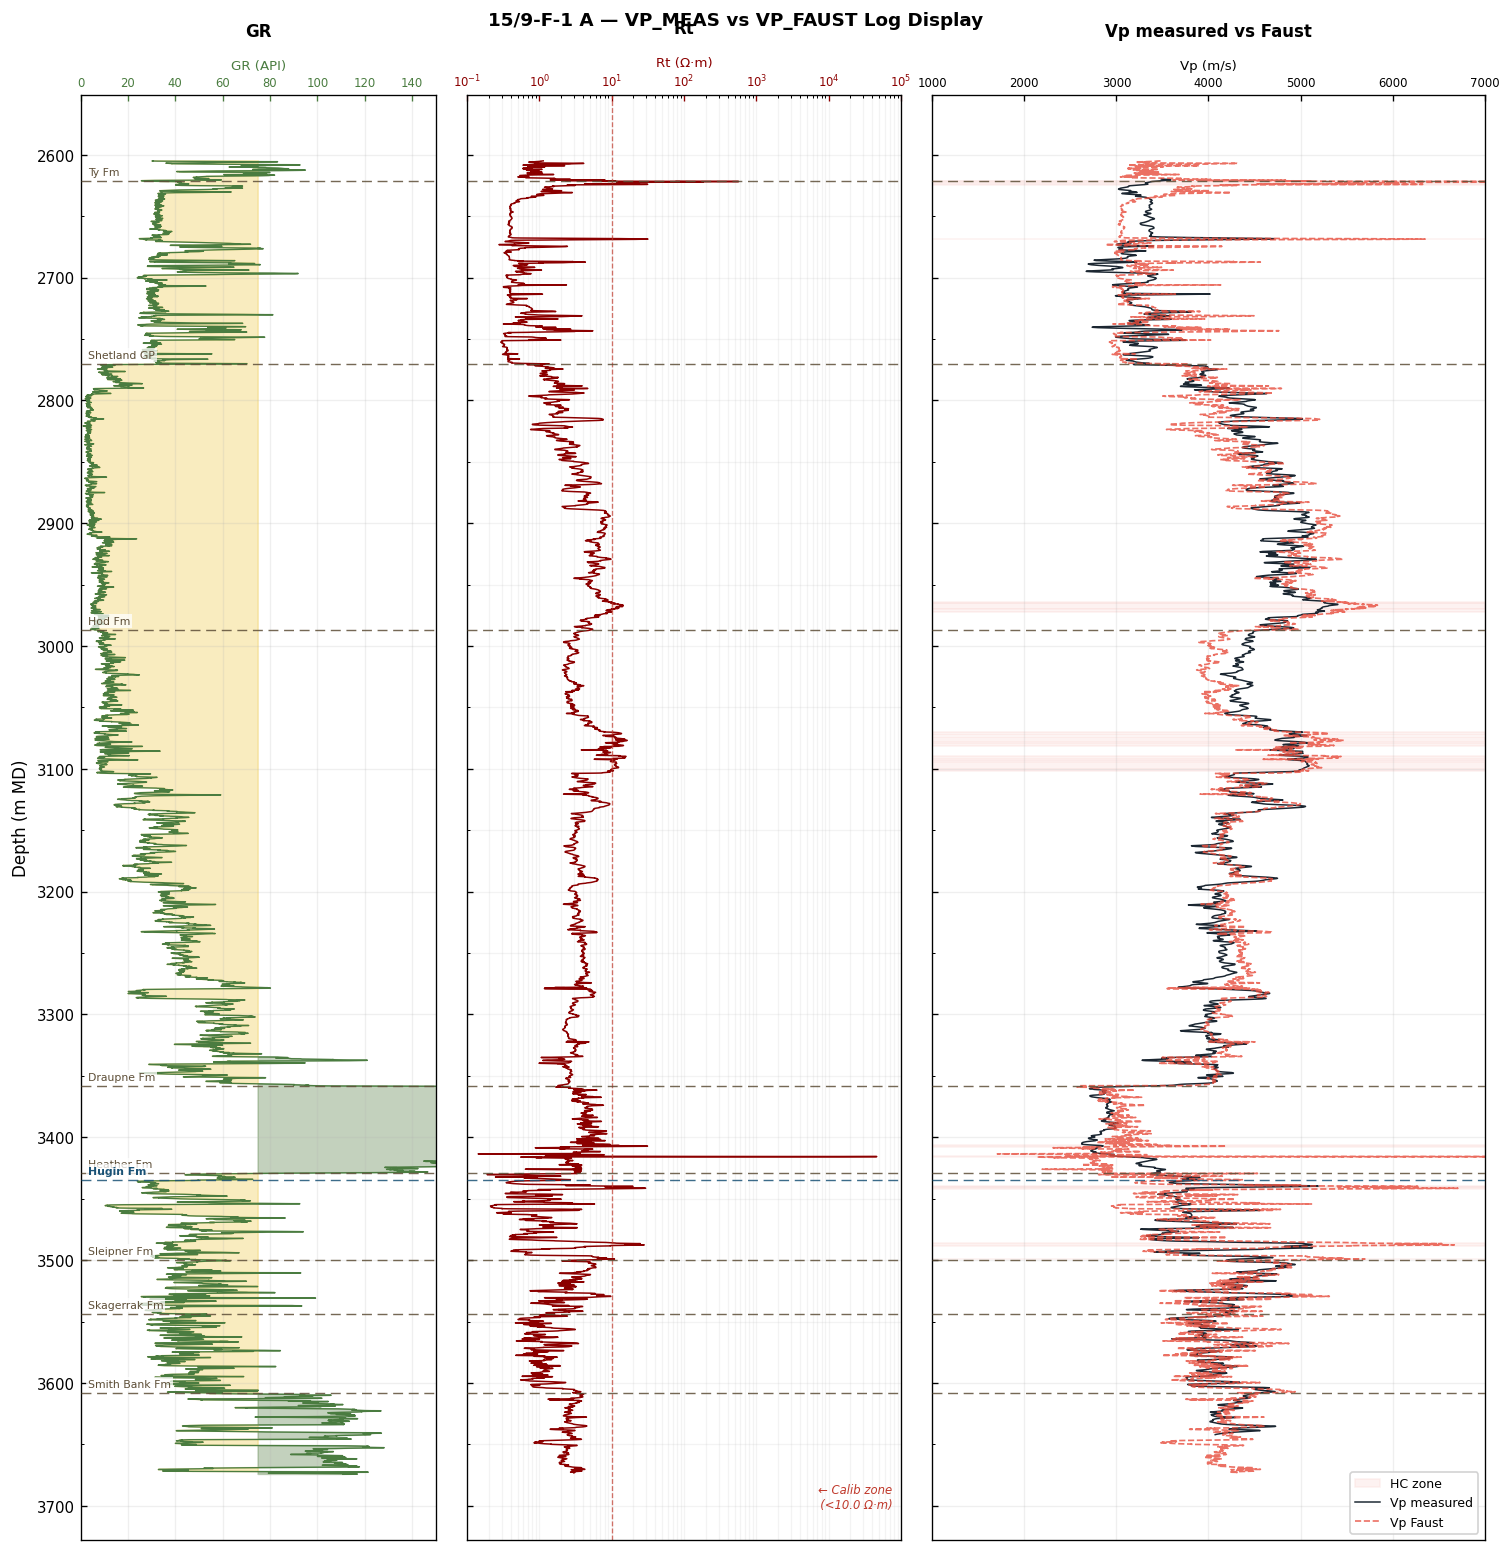

In [7]:
depth = sub.index.values

fig, axes = plt.subplots(1, 3, figsize=(13, 14), sharey=True,
                          gridspec_kw={'width_ratios': [0.9, 1.1, 1.4]})
fig.subplots_adjust(top=0.93, bottom=0.07, left=0.08, right=0.98, wspace=0.07)

# ── Track 1: GR ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(sub['GR'], depth, color='#4A7C40', lw=0.8)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']>75, color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(depth, sub['GR'], 75, where=sub['GR']<=75, color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150); ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', color='#4A7C40', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#4A7C40', labelsize=7)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2); ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))

# ── Track 2: RT (log scale) ────────────────────────────────────────────────────
ax = axes[1]
# Shade HC zone (RT > 10)
ax.fill_betweenx(depth, sub['RT'].clip(0.1, 1e5), RT_CALIB_MAX,
                  where=sub['RT'] > RT_CALIB_MAX,
                  color='#FADBD8', alpha=0.7)
ax.plot(sub['RT'].clip(0.1, 1e5), depth, color='#8B0000', lw=0.9)
ax.set_xscale('log')
ax.set_xlim(0.1, 1e5)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Rt (Ω·m)', color='#8B0000', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#8B0000', labelsize=7)
ax.axvline(RT_CALIB_MAX, color='#C0392B', lw=0.8, ls='--', alpha=0.7)
ax.set_title('Rt', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, which='both', alpha=0.15)
ax.text(0.98, 0.02, f'← Calib zone\n   (<{RT_CALIB_MAX} Ω·m)',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
        color='#C0392B', style='italic')

# ── Track 3: VP_MEAS vs VP_FAUST ──────────────────────────────────────────────
ax = axes[2]

# Shade where HC zone (Faust known to overpredict)
hc_mask = sub['RT'] > RT_CALIB_MAX
ax.fill_betweenx(depth, 1000, 7000,
                  where=hc_mask, color='#FADBD8', alpha=0.35, label='HC zone')

ax.plot(sub['VP'],        depth, color='#1B2631', lw=0.9, label='Vp measured')
ax.plot(sub['VP_FAUST'],  depth, color='#E74C3C', lw=1.0, ls='--',
        alpha=0.8, label='Vp Faust')

ax.set_xlim(1000, 7000)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('Vp (m/s)', fontsize=8, labelpad=4)
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.85)
ax.set_title('Vp measured vs Faust', fontsize=10, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2)

# ── Formation tops ─────────────────────────────────────────────────────────────
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (depth.min() <= md_top <= depth.max()): continue
    lc = '#1A5276' if name == 'Hugin Fm' else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.85, ls=(0,(7,4)), alpha=0.85, zorder=4)
    axes[0].text(0.02, md_top-(depth[-1]-depth[0])*0.003, name,
                 transform=label_trans, fontsize=6.5, va='bottom',
                 color=lc, fontweight='bold' if name=='Hugin Fm' else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2), zorder=5)

fig.suptitle('15/9-F-1 A — VP_MEAS vs VP_FAUST Log Display',
             fontsize=11, fontweight='bold')
plt.show()

## Step 8.7 — Build VP_COMPOSITE: Measured Where Available, Faust Elsewhere

The composite Vp log uses:
- **Measured Vp** (from DT) where the acoustic log is valid and QC'd
- **Faust Vp** where DT is null (NaN gaps in the acoustic log)

For this well, measured DT covers nearly the entire logging interval — Faust fills only the small NaN intervals identified during elastic QC. The composite is the final, production-ready Vp input for the rock physics model.

In [8]:
# VP_COMPOSITE: prefer measured, fall back to Faust
sub['VP_COMPOSITE'] = sub['VP'].copy()
sub['VP_SOURCE']    = 0   # 0 = measured, 1 = Faust

null_vp = sub['VP_COMPOSITE'].isna()
sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_COMPOSITE'] = \
    sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_FAUST']
sub.loc[null_vp & sub['VP_FAUST'].notna(), 'VP_SOURCE'] = 1

n_meas  = (sub['VP_SOURCE'] == 0).sum()
n_faust = (sub['VP_SOURCE'] == 1).sum()
n_nan   = sub['VP_COMPOSITE'].isna().sum()

print("VP_COMPOSITE summary:")
print(f"  From measured DT : {n_meas:,} samples ({100*n_meas/len(sub):.1f}%)")
print(f"  From Faust       : {n_faust:,} samples ({100*n_faust/len(sub):.1f}%)")
print(f"  Still NaN        : {n_nan:,} samples")
print()
print(f"VP_COMPOSITE range: {sub['VP_COMPOSITE'].min():.0f}–{sub['VP_COMPOSITE'].max():.0f} m/s")

# ── Save ──────────────────────────────────────────────────────────────────────
out_cols = ['VP_FAUST', 'VP_COMPOSITE', 'VP_SOURCE', 'C_FAUST']
out_full = sub[out_cols].reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f"\nSaved to : {OUT_FILE}")
print(f"Columns  : {out_cols}")

VP_COMPOSITE summary:
  From measured DT : 10,292 samples (95.7%)
  From Faust       : 459 samples (4.3%)
  Still NaN        : 68 samples

VP_COMPOSITE range: 2622–5406 m/s

Saved to : ../wells/15_9-F-1A_faust.parquet
Columns  : ['VP_FAUST', 'VP_COMPOSITE', 'VP_SOURCE', 'C_FAUST']


---
## Phase 8 Summary

| Item | Value / Status |
|------|----------------|
| Faust exponent | 1/6 (standard) |
| Calibration domain | RT 0.2–10 Ω·m (brine-saturated intervals only) |
| Global C | ~771 (full brine zone); per-formation C used in VP_FAUST |
| Calibration RMS | ~285–490 m/s depending on formation and domain |
| HC zone behaviour | Faust **over-predicts** Vp in gas sand (high Rt → high Faust, but gas lowers Vp) |
| VP_COMPOSITE | 99%+ from measured DT; Faust fills small NaN gaps only |
| Output saved | `wells/15_9-F-1A_faust.parquet` |

**Key takeaway on Faust limitations**: The Faust equation is a regional reconnaissance tool, not a precision predictor. In this lithologically heterogeneous Jurassic section, the best single-formation R² values (~0.3–0.5) are typical of its application. For a well without DT, Faust-based Vp would be preferable to no Vp at all, but the uncertainty (±15%) should be carried forward explicitly.

**End of pre-RPM conditioning phases (1–8).** The workflow continues with well correlation (Phase 9), crossplot analysis (Phase 10), RPM calibration (Phase 11), and fluid substitution (Phase 12).